In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("data/SuperMarket Analysis.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(1000, 17)
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905       26.1415 

DATA CLEANING 

In [8]:
print(df.isnull().sum())
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
# Tell pandas to automatically infer the format for each row
df['Hour'] = pd.to_datetime(df['Time'], format='mixed').dt.hour
print(df[['Date', 'Month', 'Time', 'Hour']]. head())

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
Month                      0
dtype: int64
        Date     Month         Time  Hour
0 2019-01-05   January   1:08:00 PM    13
1 2019-03-08     March  10:29:00 AM    10
2 2019-03-03     March   1:23:00 PM    13
3 2019-01-27   January   8:33:00 PM    20
4 2019-02-08  February  10:37:00 AM    10


REVENUE ANALYSIS

In [15]:
branch_sales = df.groupby('Branch') ['Sales'].sum().reset_index()
print(branch_sales)

product_sales = df.groupby('Product line')['Sales'].sum().sort_values(ascending = False)
print(product_sales)

  Branch        Sales
0   Alex  106200.3705
1  Cairo  106197.6720
2   Giza  110568.7065
Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


VISUALIZATION

C:\Users\hp\AppData\Local\Temp\ipykernel_23028\1312442337.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x = 'Product line', y = 'Sales', estimator = sum, ci = None)


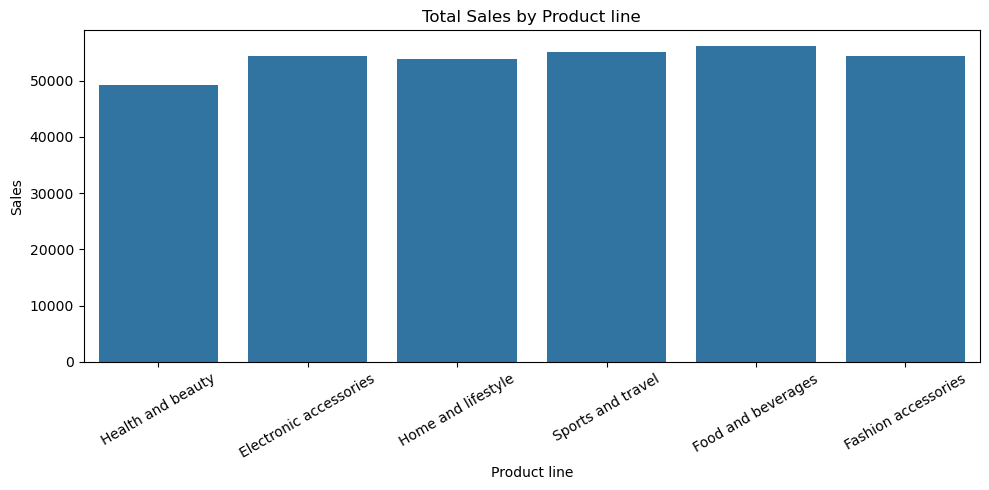

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x = 'Product line', y = 'Sales', estimator = sum, ci = None)
plt.title('Total Sales by Product line')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

peak shopping hours

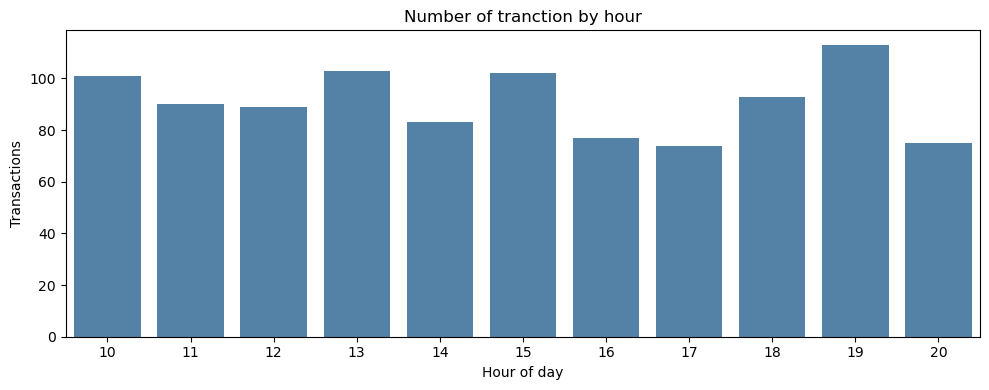

In [19]:
plt.figure(figsize = (10,4))
sns.countplot(data = df, x = 'Hour', color = 'steelblue')
plt.title('Number of tranction by hour')
plt.xlabel('Hour of day')
plt.ylabel('Transactions')
plt.tight_layout()
plt.show()

revenue trend over months

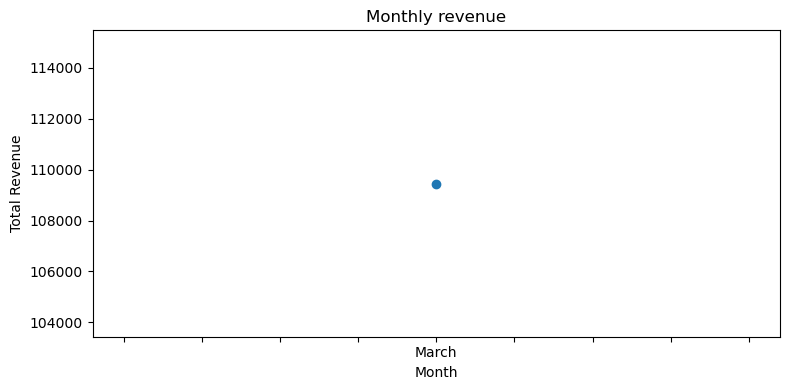

In [21]:
monthly = df.groupby('Month')['Sales'].sum()
monthly_order = ['january', 'february', 'March']
monthly = monthly.reindex(monthly_order)

monthly.plot(kind = 'line', marker = 'o', figsize = (8,4), title = 'Monthly revenue')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

correlation heatmap

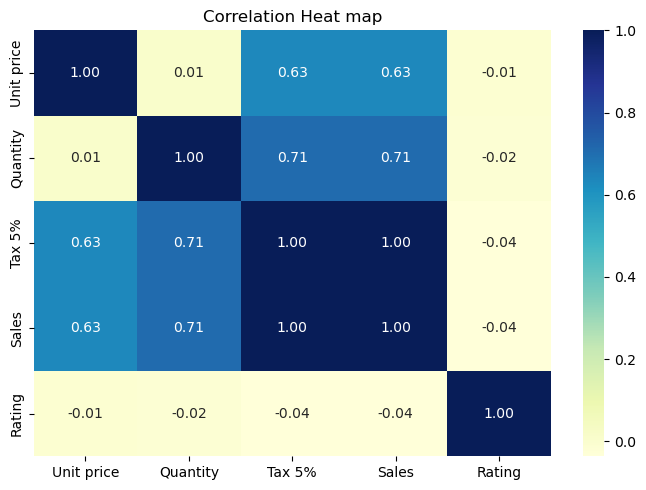

In [23]:
numeric_cols = df[['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Rating']]
plt.figure(figsize = (7,5))
sns.heatmap(numeric_cols.corr(), annot = True, cmap = 'YlGnBu', fmt = '.2f')
plt.title('Correlation Heat map')
plt.tight_layout()
plt.show()
